<a href="https://colab.research.google.com/github/DengDuangLang111/494-algo-representations/blob/task2/494task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import os
import glob

base_path = '/content/drive/MyDrive/494data'
target_ts = 1759190400000  # 2025-09-30

print("=== Step 1: Processing with RATER Factors ===")

print("[A] Loading Rater Factors...")
rater_factors_path = os.path.join(base_path, 'prescoringRaterModelOutput_1dim.tsv')
df_rater_factors = pd.read_csv(rater_factors_path, sep='\t',
                               usecols=['raterParticipantId', 'internalRaterFactor1'])

if 'internalRaterFactor1' not in df_rater_factors.columns:
    cols = [c for c in df_rater_factors.columns if 'Factor1' in c]
    if cols:
        df_rater_factors.rename(columns={cols[0]: 'internalRaterFactor1'}, inplace=True)

print(f"Loaded {len(df_rater_factors)} Rater Factors.")

print("\n[B] Loading Note Status History...")
status_files = glob.glob(os.path.join(base_path, 'noteStatusHistory-*.zip'))
if not status_files:
    status_files = glob.glob(os.path.join(base_path, 'noteStatusHistory-*.tsv'))

df_status_list = []
status_cols = ['noteId', 'timestampMillisOfFirstNonNMRStatus']

for f in status_files:
    try:
        chunk = pd.read_csv(f, sep='\t', usecols=lambda c: c in status_cols, dtype={'noteId': str})
        chunk = chunk.drop_duplicates(subset=['noteId'], keep='last')
        df_status_list.append(chunk)
    except Exception as e:
        print(f"Error reading status {os.path.basename(f)}: {e}")

if df_status_list:
    df_status = pd.concat(df_status_list, ignore_index=True)
    df_status = df_status.drop_duplicates(subset=['noteId'], keep='last')
    print(f"Status loaded for {len(df_status)} notes.")
else:
    print("Warning: No status history found.")
    df_status = pd.DataFrame(columns=status_cols)

print("\n[C] Processing Ratings (Merging Rater Factors)...")
rating_files = glob.glob(os.path.join(base_path, 'ratings-*.zip'))
processed_chunks = []

cols_to_keep = ['noteId', 'raterParticipantId', 'createdAtMillis', 'ratingSourceBucketed']

for f in rating_files:
    print(f"Scanning: {os.path.basename(f)} ...")
    try:
        chunk_iter = pd.read_csv(f, sep='\t', usecols=lambda c: c in cols_to_keep,
                                 chunksize=100000, dtype={'noteId': str, 'raterParticipantId': str})

        for chunk in chunk_iter:
            chunk = chunk[chunk['createdAtMillis'] >= target_ts]

            if chunk.empty:
                continue

            chunk = chunk.merge(df_rater_factors, on='raterParticipantId', how='inner')

            if chunk.empty:
                continue

            chunk = chunk.merge(df_status, on='noteId', how='left')

            conditions = [
                chunk['timestampMillisOfFirstNonNMRStatus'].isna(),
                chunk['createdAtMillis'] < chunk['timestampMillisOfFirstNonNMRStatus']
            ]
            choices = ['pre', 'pre']

            chunk['stage'] = np.select(conditions, choices, default='post')

            final_chunk = chunk[['noteId', 'raterParticipantId', 'internalRaterFactor1', 'stage', 'ratingSourceBucketed']]
            processed_chunks.append(final_chunk)

    except Exception as e:
        print(f"Error processing {os.path.basename(f)}: {e}")

if processed_chunks:
    df_final = pd.concat(processed_chunks, ignore_index=True)

    print("\n=== Final Data Statistics ===")
    print(f"Total Ratings with Known Rater Factors: {len(df_final)}")
    print("Source Distribution:")
    print(df_final['ratingSourceBucketed'].value_counts())
    print("Stage Distribution:")
    print(df_final['stage'].value_counts())

    output_file = os.path.join(base_path, 'step1_rater_analysis.parquet')
    df_final.to_parquet(output_file)
    print(f"\nSaved to: {output_file}")
else:
    print("\nError: No data matched! (This means no new ratings came from old users)")

=== Step 1: Processing with RATER Factors ===
[A] Loading Rater Factors...
Loaded 671690 Rater Factors.

[B] Loading Note Status History...
Status loaded for 2593861 notes.

[C] Processing Ratings (Merging Rater Factors)...
Scanning: ratings-00005.zip ...
Scanning: ratings-00001.zip ...
Scanning: ratings-00006.zip ...
Scanning: ratings-00002 (1).zip ...
Scanning: ratings-00004.zip ...
Scanning: ratings-00000.zip ...
Scanning: ratings-00003 (1).zip ...

=== Final Data Statistics ===
Total Ratings with Known Rater Factors: 19407542
Source Distribution:
ratingSourceBucketed
DEFAULT               19036866
POPULATION_SAMPLED      370676
Name: count, dtype: int64
Stage Distribution:
stage
pre     17308073
post     2099469
Name: count, dtype: int64

Saved to: /content/drive/MyDrive/494data/step1_rater_analysis.parquet


Loading data for Step 2 plotting...
Data loaded: 19407542 rows.
Generating 3x2 Density Plots...


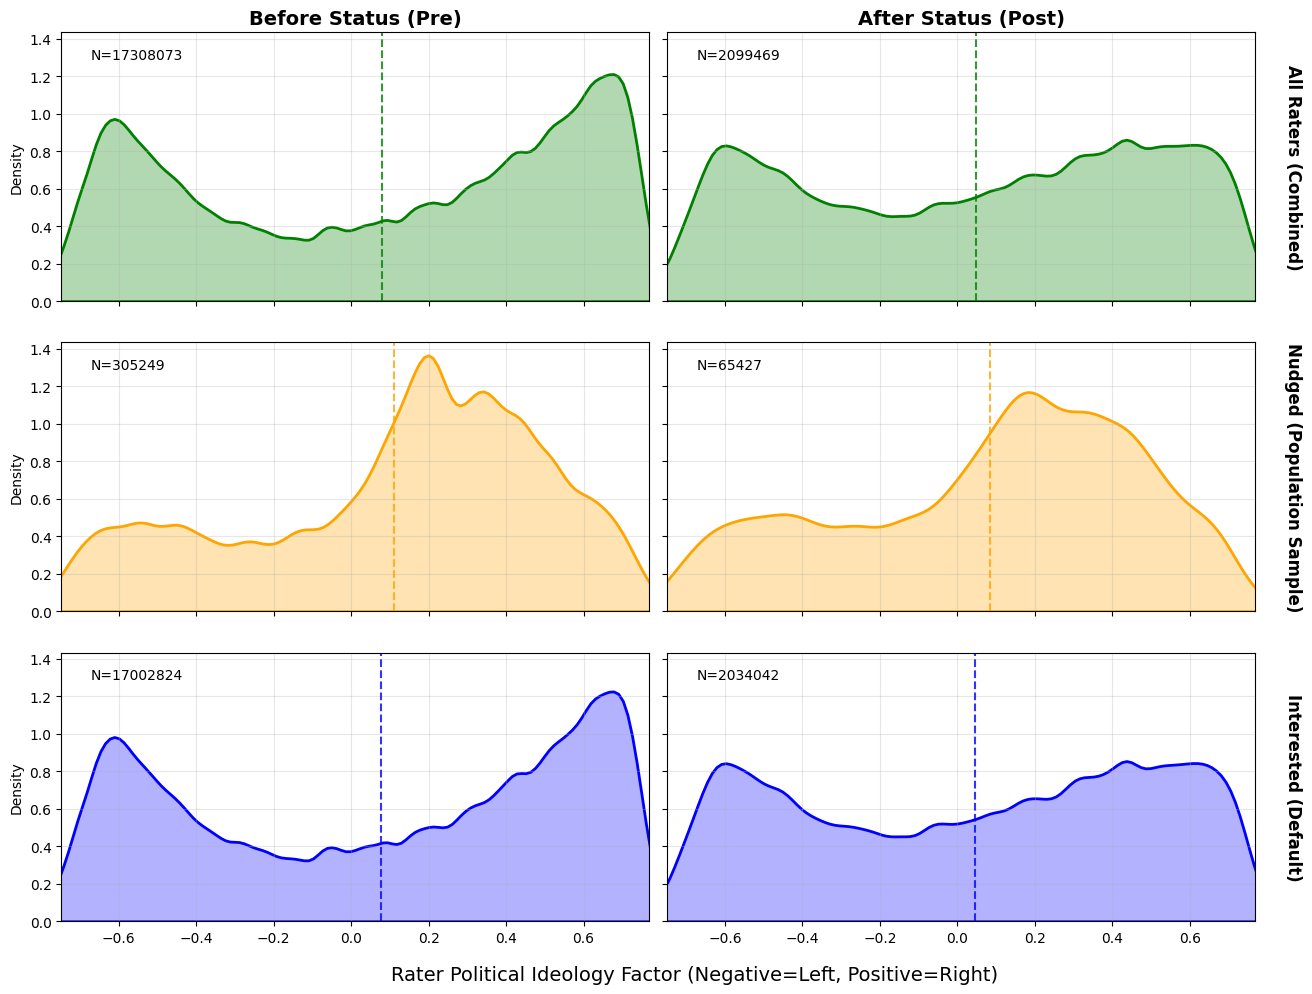

Step 2 Complete!


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

base_path = '/content/drive/MyDrive/494data'
input_file = os.path.join(base_path, 'step1_rater_analysis.parquet')

print("Loading data for Step 2 plotting...")

if not os.path.exists(input_file):
    raise FileNotFoundError(f"Input file not found: {input_file}. Please run Step 1 first.")

df = pd.read_parquet(input_file)
print(f"Data loaded: {len(df)} rows.")

xmin = np.nanpercentile(df["internalRaterFactor1"], 1)
xmax = np.nanpercentile(df["internalRaterFactor1"], 99)

print("Generating 3x2 Density Plots...")

row_order = ["All Raters (Combined)", "Nudged (Population Sample)", "Interested (Default)"]
col_order = ["pre", "post"]
col_titles = {"pre": "Before Status (Pre)", "post": "After Status (Post)"}

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 10), sharex=True, sharey=True)

for r, row_name in enumerate(row_order):
    for c, stage in enumerate(col_order):
        ax = axes[r, c]

        if row_name == "All Raters (Combined)":
            sub = df[df["stage"] == stage]
            color = "green"
        elif row_name == "Nudged (Population Sample)":
            sub = df[(df["stage"] == stage) & (df["ratingSourceBucketed"] == "POPULATION_SAMPLED")]
            color = "orange"
        else:
            sub = df[(df["stage"] == stage) & (df["ratingSourceBucketed"] == "DEFAULT")]
            color = "blue"

        if len(sub) > 100:
            sns.kdeplot(
                data=sub,
                x="internalRaterFactor1",
                ax=ax,
                fill=True,
                alpha=0.3,
                color=color,
                linewidth=2,
                bw_adjust=1.0
            )

            mean_val = sub["internalRaterFactor1"].mean()
            ax.axvline(mean_val, color=color, linestyle='--', alpha=0.8, label=f'Mean: {mean_val:.2f}')

            ax.text(0.05, 0.9, f"N={len(sub)}", transform=ax.transAxes, fontsize=10)
        else:
            ax.text(0.5, 0.5, "Not enough data", ha='center', transform=ax.transAxes)

        ax.set_xlim(xmin, xmax)

        ax.set_ylabel("Density" if c == 0 else "")
        ax.set_xlabel("")

        if r == 0:
            ax.set_title(col_titles[stage], fontsize=14, fontweight='bold')

        if c == 1:
            ax.text(1.05, 0.5, row_name, transform=ax.transAxes,
                    fontsize=12, rotation=270, va='center', fontweight='bold')

        ax.grid(True, alpha=0.3)

# Global Labels and Layout Adjustment
fig.supxlabel("Rater Political Ideology Factor (Negative=Left, Positive=Right)", fontsize=14)
plt.tight_layout()
plt.subplots_adjust(right=0.9) # Adjust space for row labels
plt.show()

print("Step 2 Complete!")

In [4]:
from scipy.stats import entropy

# Configuration
base_path = '/content/drive/MyDrive/494data'
input_file = os.path.join(base_path, 'step1_rater_analysis.parquet')

print("Loading data for Step 3 (Metrics)...")
if not os.path.exists(input_file):
    raise FileNotFoundError("Input file not found.")

df = pd.read_parquet(input_file)
print(f"Data loaded: {len(df)} rows.")

# === Define Metric Functions ===

def calculate_metrics(series):
    var_val = series.var()

    if len(series) > 10000:
        sample = np.random.choice(series, 10000, replace=False)
    else:
        sample = series.values

    sample.sort()
    n = len(sample)
    if n > 1:
        cumulative_sum = np.cumsum(sample)
        coef = 2 / (n * (n - 1))
        total_diff = 2 * np.sum((np.arange(1, n + 1) * sample) - np.cumsum(sample))
        pass

    counts, _ = np.histogram(series, bins=20, range=(-1.5, 1.5))
    probs = counts / len(series)
    probs = probs[probs > 0]
    ent = entropy(probs, base=2)
    max_ent = np.log2(20)
    norm_ent = ent / max_ent

    return pd.Series({'Variance': var_val, 'Normalized_Entropy': norm_ent, 'N': len(series)})

print("Calculating Metrics by Group and Stage...")
grouped_metrics = df.groupby(['stage', 'ratingSourceBucketed'])['internalRaterFactor1'].apply(calculate_metrics).unstack()

print("\n=== Final Diversity Metrics ===")
print(grouped_metrics)

grouped_metrics = grouped_metrics.round(4)
output_csv = os.path.join(base_path, 'step3_diversity_metrics.csv')
grouped_metrics.to_csv(output_csv)
print(f"\nMetrics saved to: {output_csv}")

print("\nCalculating Combined Metrics...")
combined_metrics = df.groupby(['stage'])['internalRaterFactor1'].apply(calculate_metrics).unstack()
combined_metrics['ratingSourceBucketed'] = 'COMBINED'
print(combined_metrics)

Loading data for Step 3 (Metrics)...
Data loaded: 19407542 rows.
Calculating Metrics by Group and Stage...

=== Final Diversity Metrics ===
                            Variance  Normalized_Entropy           N
stage ratingSourceBucketed                                          
post  DEFAULT               0.208222            0.786615   2034042.0
      POPULATION_SAMPLED    0.147238            0.755448     65427.0
pre   DEFAULT               0.246447            0.775499  17002824.0
      POPULATION_SAMPLED    0.151947            0.750759    305249.0

Metrics saved to: /content/drive/MyDrive/494data/step3_diversity_metrics.csv

Calculating Combined Metrics...
       Variance  Normalized_Entropy           N ratingSourceBucketed
stage                                                               
post   0.206158            0.786413   2099469.0             COMBINED
pre    0.244462            0.776212  17308073.0             COMBINED


In [8]:
import pandas as pd
import numpy as np
import os
import glob
from scipy.stats import entropy

input_file = os.path.join(base_path, 'step1_rater_analysis.parquet')

df = pd.read_parquet(input_file)
df['noteId'] = df['noteId'].astype(str)

def calculate_metrics(series):
    if len(series) < 2:
        return pd.Series({'Variance': np.nan, 'Rao_Distance': np.nan, 'Normalized_Entropy': np.nan, 'N': len(series)})

    x = series.dropna().values
    var_val = x.var()

    sample = np.random.choice(x, min(1000, len(x)), replace=False)
    rao_val = np.mean(np.abs(sample[:, None] - sample[None, :]))

    counts, _ = np.histogram(x, bins=20, range=(-1.5, 1.5))
    probs = counts[counts > 0] / len(x)
    ent = entropy(probs, base=2)
    norm_ent = ent / np.log2(20)

    return pd.Series({'Variance': var_val, 'Rao_Distance': rao_val, 'Normalized_Entropy': norm_ent, 'N': len(x)})

print("Computing global metrics for Step 3...")
metrics_table = df.groupby(['stage', 'ratingSourceBucketed'])['internalRaterFactor1'].apply(calculate_metrics).unstack()
print("\n[Final Metrics Table]:")
print(metrics_table.round(4))

print("\nSearching for Status History file...")
status_pattern = os.path.join(base_path, "noteStatusHistory*")
status_candidates = glob.glob(status_pattern)

if not status_candidates:
    print("Error: Could not find noteStatusHistory file!")
else:
    status_path = status_candidates[0]
    print(f"Loading status from: {os.path.basename(status_path)}")
    status = pd.read_csv(status_path, sep='\t', low_memory=False)
    status['noteId'] = status['noteId'].astype(str)
    status['flip'] = (status['firstNonNMRStatus'] != status['mostRecentNonNMRStatus']).astype(int)

    df_flip = df.merge(status[['noteId', 'flip']], on='noteId', how='left').dropna(subset=['flip'])

    flip_comparison = df_flip.groupby(['flip', 'stage'])['internalRaterFactor1'].apply(calculate_metrics).unstack()

    print("\n[Flip Status vs Diversity Metrics]:")
    print(flip_comparison.round(4))

    metrics_table.to_csv(os.path.join(base_path, 'final_metrics_summary.csv'))
    flip_comparison.to_csv(os.path.join(base_path, 'flip_diversity_analysis.csv'))
    print("\nAll tasks complete and files saved.")

Computing global metrics for Step 3...

[Final Metrics Table]:
                            Variance  Rao_Distance  Normalized_Entropy  \
stage ratingSourceBucketed                                               
post  DEFAULT                 0.2082        0.5253              0.7866   
      POPULATION_SAMPLED      0.1472        0.4234              0.7554   
pre   DEFAULT                 0.2464        0.5839              0.7755   
      POPULATION_SAMPLED      0.1519        0.4456              0.7508   

                                    N  
stage ratingSourceBucketed             
post  DEFAULT               1097459.0  
      POPULATION_SAMPLED      39359.0  
pre   DEFAULT               8312813.0  
      POPULATION_SAMPLED     180288.0  

Searching for Status History file...
Loading status from: noteStatusHistory-00000 (1).zip

[Flip Status vs Diversity Metrics]:
            Variance  Rao_Distance  Normalized_Entropy          N
flip stage                                                